In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("cleaned_netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


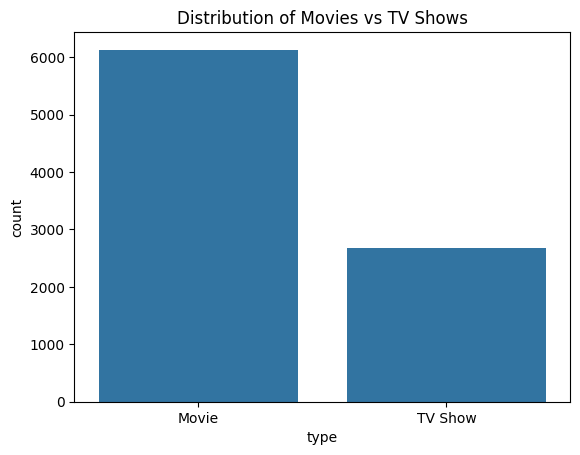

In [3]:
content_type = df["type"].value_counts()

sns.countplot(data=df, x="type")
plt.title("Distribution of Movies vs TV Shows")
plt.show()

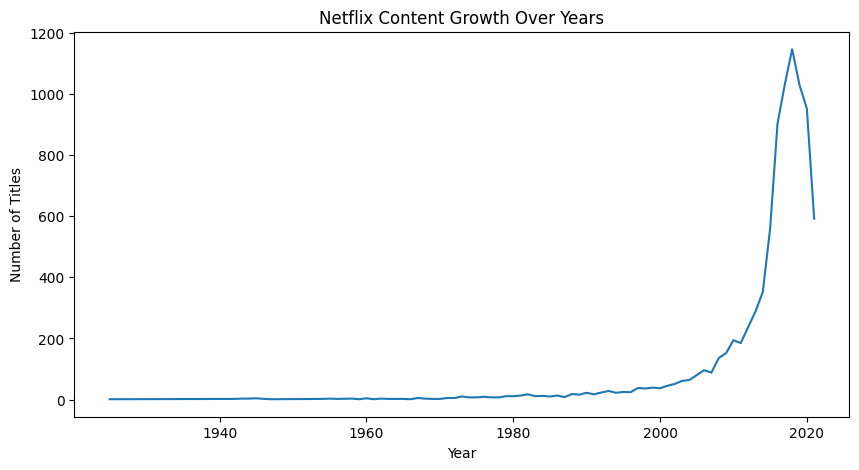

In [4]:
content_growth = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
content_growth.plot()
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

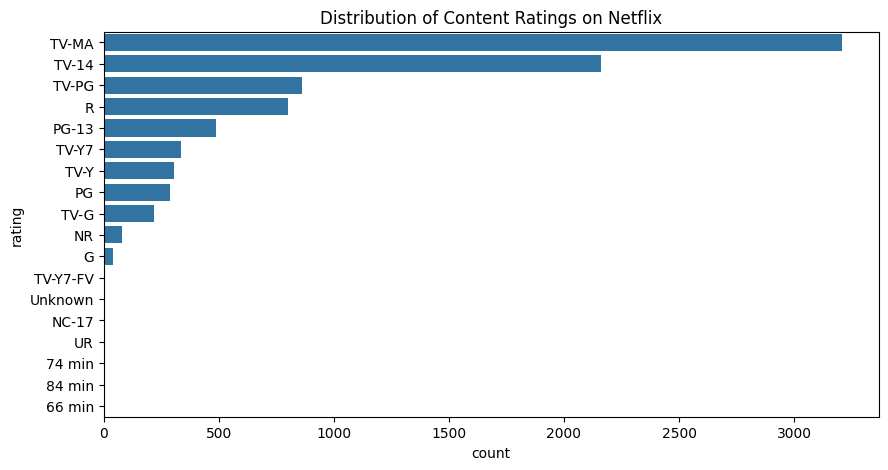

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="rating", order=df["rating"].value_counts().index)
plt.title("Distribution of Content Ratings on Netflix")
plt.show()

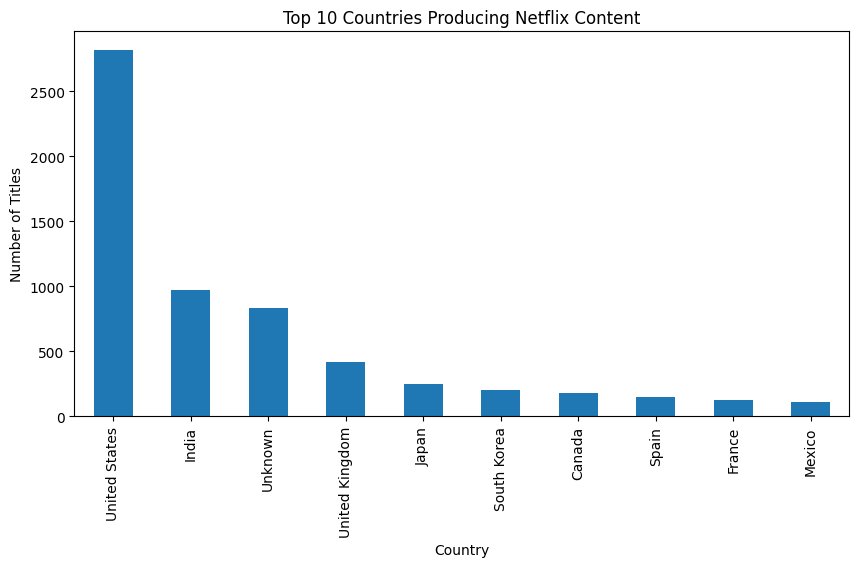

In [6]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

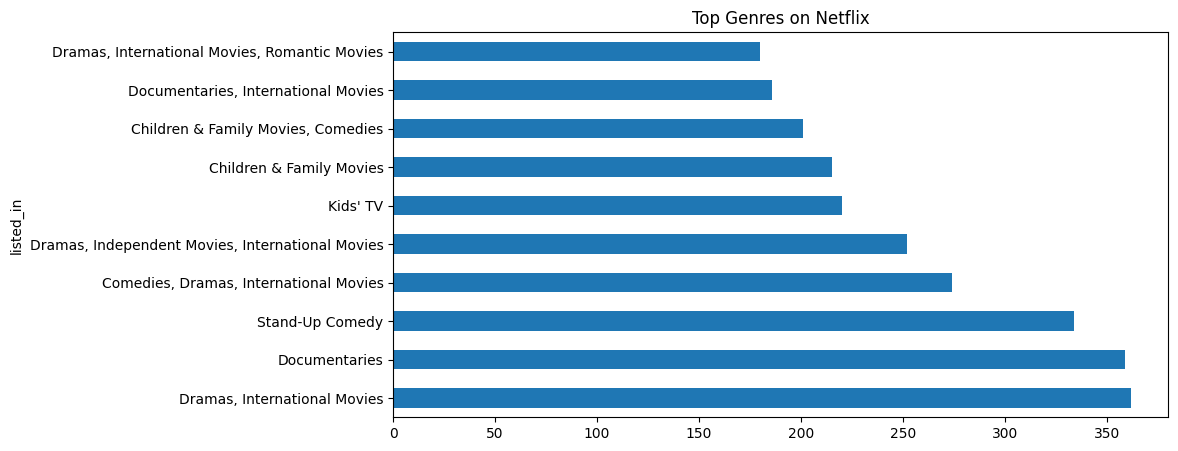

In [7]:
top_genres = df["listed_in"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind="barh")
plt.title("Top Genres on Netflix")
plt.show()

In [9]:
df["content_length_category"] = df["duration"].apply(
    lambda x: "Short" if "min" in str(x) and int(x.split()[0]) < 90 else "Long"
)

In [10]:
df["content_length_category"].value_counts()

content_length_category
Long     6969
Short    1838
Name: count, dtype: int64

In [11]:
df.to_csv("feature_engineered_netflix.csv", index=False)

In [12]:
df["content_age"] = 2026 - df["release_year"]

In [13]:
df[["title","release_year","content_age"]].head()

,title,release_year,content_age
0,Dick Johnson Is Dead,2020,6
1,Blood & Water,2021,5
2,Ganglands,2021,5
3,Jailbirds New Orleans,2021,5
4,Kota Factory,2021,5
